# Recurr

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler

In [3]:
prices = np.array([100, 102, 101, 105, 107, 110, 108, 111, 115, 117])
prices = prices.reshape(-1, 1)

In [4]:
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

In [5]:
X = []
y = []

for i in range(3, len(prices_scaled)):
    X.append(prices_scaled[i-3:i])
    y.append(prices_scaled[i])

In [6]:
X = np.array(X)
y = np.array(y)

In [7]:
print(X.shape)

(7, 3, 1)


In [8]:
model = Sequential()

In [9]:
model.add(SimpleRNN(5, activation='relu', input_shape=(3,1)))
model.add(Dense(1))

C:\Users\HP\.conda\envs\tf\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [11]:
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3061
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2798
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2512
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2237
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1919
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1682
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1496
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1247
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1070
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0904 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0743
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0591 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0507 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0390
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0317
Epoch 16/100
7/7

In [12]:
predicted = model.predict(X)
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step


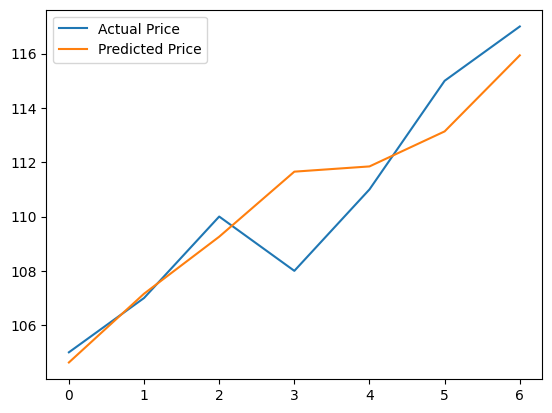

In [13]:
plt.plot(real_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")
plt.legend()
plt.show()